## Multiple Linear Regression

* More than one independent features are present in the dataset

In [45]:
from sklearn.datasets import fetch_california_housing

In [46]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [47]:
california = fetch_california_housing()

In [48]:
print(california.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])


In [49]:
print(california.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [50]:
california.target_names

['MedHouseVal']

In [51]:
print(california.data)

[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]


In [52]:
print(california.target)

[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [53]:
california.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [54]:
## Preparing the dataset
dataset = pd.DataFrame(california.data, columns=california.feature_names)
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [55]:
dataset['Price'] = california.target

In [56]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [57]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [58]:
## Check for missing values
dataset.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
Price,0


In [59]:
## Get Statistical summary of the dataset
dataset.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [60]:
dataset.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
Price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


<Axes: >

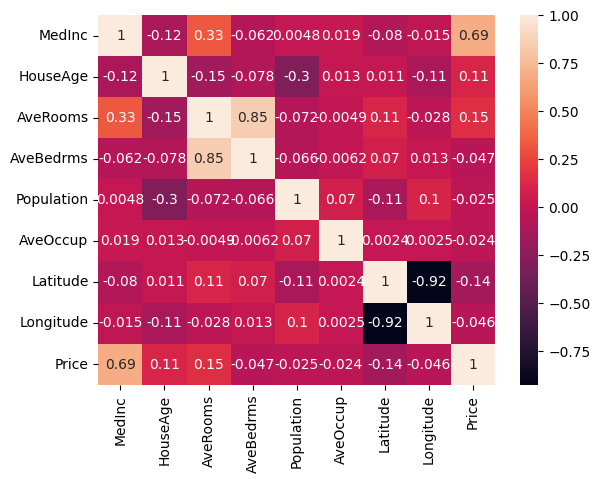

In [61]:
## Plotting a heatmap for the correlation
import seaborn as sns
sns.heatmap(dataset.corr(),annot=True)

In [62]:
## Independent and Dependent features

X = dataset.iloc[:,:-1] # Independent features
y = dataset.iloc[:,-1] # Dependent feature

In [63]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [64]:
from sklearn.model_selection import train_test_split

In [65]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.33, random_state=10)

In [66]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((13828, 8), (6812, 8), (13828,), (6812,))

#### Standardize the dataset

In [67]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [68]:
X_train = scaler.fit_transform(X_train)

In [69]:
X_test = scaler.transform(X_test)

In [70]:
X_train, X_test

(array([[-0.72986836,  1.22081889, -0.70305988, ...,  0.05861244,
          0.96929441, -1.43979718],
        [-0.61046678, -0.28439808,  0.07828001, ...,  0.13015917,
         -0.75823526,  1.08204942],
        [ 0.00784578, -0.60128586, -0.2447376 , ..., -0.09793279,
          0.94594941, -1.2454256 ],
        ...,
        [ 0.88684913, -1.78961504, -0.21300658, ...,  0.09549475,
          0.78720344, -1.10587678],
        [-0.87672223,  0.50782138, -1.10043274, ...,  0.18513096,
         -0.77224225,  0.66838683],
        [-0.62742573, -0.99739558, -0.60483749, ..., -0.08418874,
          0.77786545, -1.15073176]]),
 array([[ 0.75154854, -1.31428337, -0.39376169, ...,  0.12606697,
         -0.68820027,  0.19491761],
        [ 0.05935857, -0.12595418, -0.33070668, ..., -0.12021013,
          0.89459042, -1.36503888],
        [ 0.34405687, -1.31428337, -0.41007104, ..., -0.15581759,
         -0.91698123,  0.89764561],
        ...,
        [ 0.36483158,  0.27015554,  0.04216837, ..., -

#### Training the Model

In [71]:
from sklearn.linear_model import LinearRegression

In [72]:
model = LinearRegression()

In [73]:
model

LinearRegression()

In [74]:
model.fit(X_train, y_train)

LinearRegression()

In [75]:
# Slope or coefficients
print(model.coef_)

[ 0.82872299  0.1231163  -0.27068752  0.32859106  0.00213572 -0.02810091
 -0.93017985 -0.89505497]


In [76]:
# Intercepets
print(model.intercept_)

2.0634768086491184


In [77]:
## Prediction for the test data

y_pred = model.predict(X_test)

In [78]:
y_pred

array([3.00397485, 2.58011486, 2.3489077 , ..., 3.09003708, 0.79152007,
       2.04477012])

#### Performance Metrics

In [79]:
from sklearn.metrics import *

print("MSE:",mean_squared_error(y_test, y_pred))
print("MAE:",mean_absolute_error(y_test, y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test, y_pred)))

MSE: 0.5522332399363619
MAE: 0.5371056943007959
RMSE: 0.7431239734636219


In [82]:
## R-square and Adjusted R-square

score = r2_score(y_test,y_pred)
print("R2 Score:",score)

print("Adjusted R2 Score:",1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

R2 Score: 0.593595852643664
Adjusted R2 Score: 0.5931179409607519


## Assumptions

Text(0, 0.5, 'Test Predicted Data')

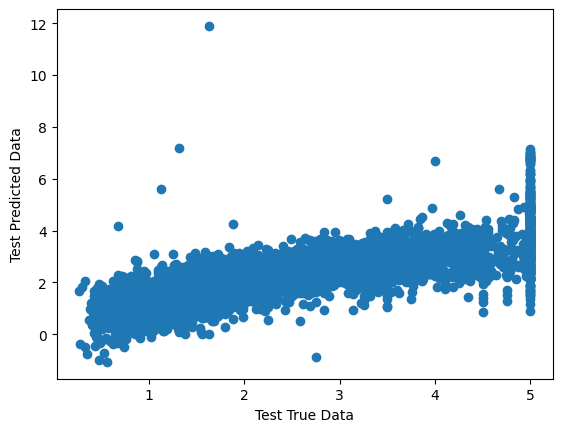

In [83]:
plt.scatter(y_test, y_pred)
plt.xlabel("Test True Data")
plt.ylabel("Test Predicted Data")

In [84]:
residuals = y_test - y_pred

In [85]:
residuals

,Price
20303,-1.329975
16966,0.960885
10623,-0.746908
6146,-0.307462
2208,-0.662167
...,...
13490,-0.243475
9340,0.507182
17439,-1.366037
2602,0.046480


<Axes: xlabel='Price', ylabel='Count'>

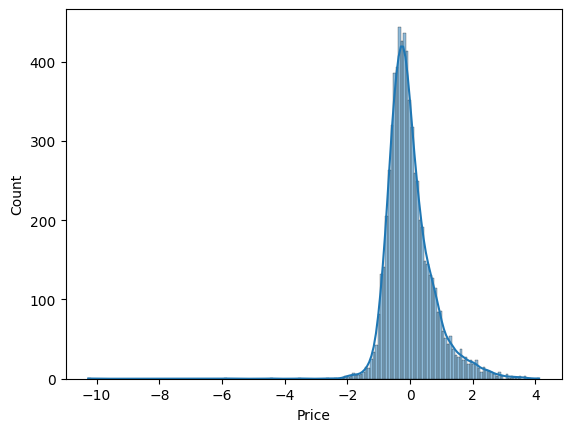

In [87]:
sns.histplot(residuals, kde=True)

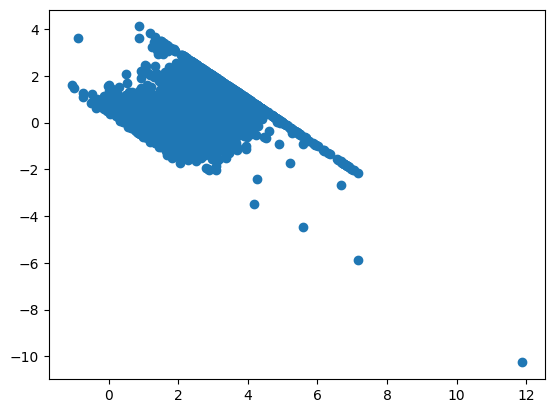

In [88]:
## Scatter plot with predictions and residuals
## Uniform distribution

plt.scatter(y_pred, residuals)

## Piclking

Python pickle module is used for serialising and de-serialising a Python Object Structure. Any object in python can be pickled so that it can be saved on disk.

In [89]:
import pickle
pickle.dump(model, open('multiple_regressor.pkl', 'wb'))